Rows after cleaning: 3,227 / 4,803


,budget,revenue,popularity,runtime,vote_average,vote_count
count,3.227000e+03,3.227000e+03,3227.00,3227.00,3227.00,3227.00
mean,4.067877e+07,1.213181e+08,29.05,110.72,6.31,977.89
std,4.439974e+07,1.863361e+08,36.17,20.97,0.86,1414.54
min,1.000000e+00,5.000000e+00,0.02,41.00,2.30,1.00
25%,1.050000e+07,1.704008e+07,10.48,96.00,5.80,178.00
50%,2.500000e+07,5.519828e+07,20.42,107.00,6.30,471.00
75%,5.500000e+07,1.463949e+08,37.35,121.00,6.90,1148.00
max,3.800000e+08,2.787965e+09,875.58,338.00,8.50,13752.00


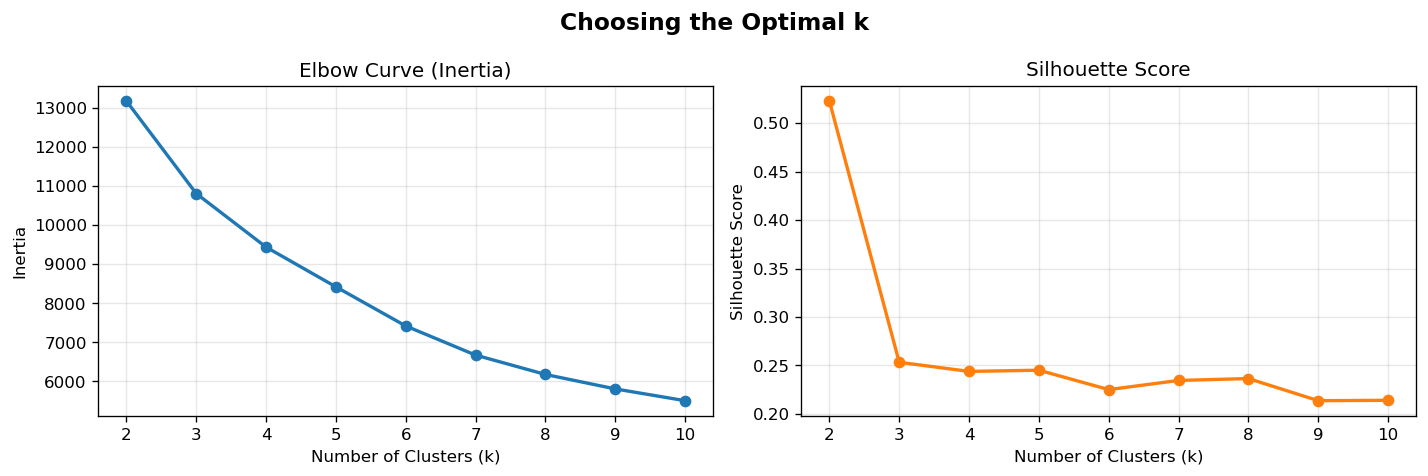


Cluster sizes (k=4):


,count
cluster,
0,1249
1,1440
2,98
3,440


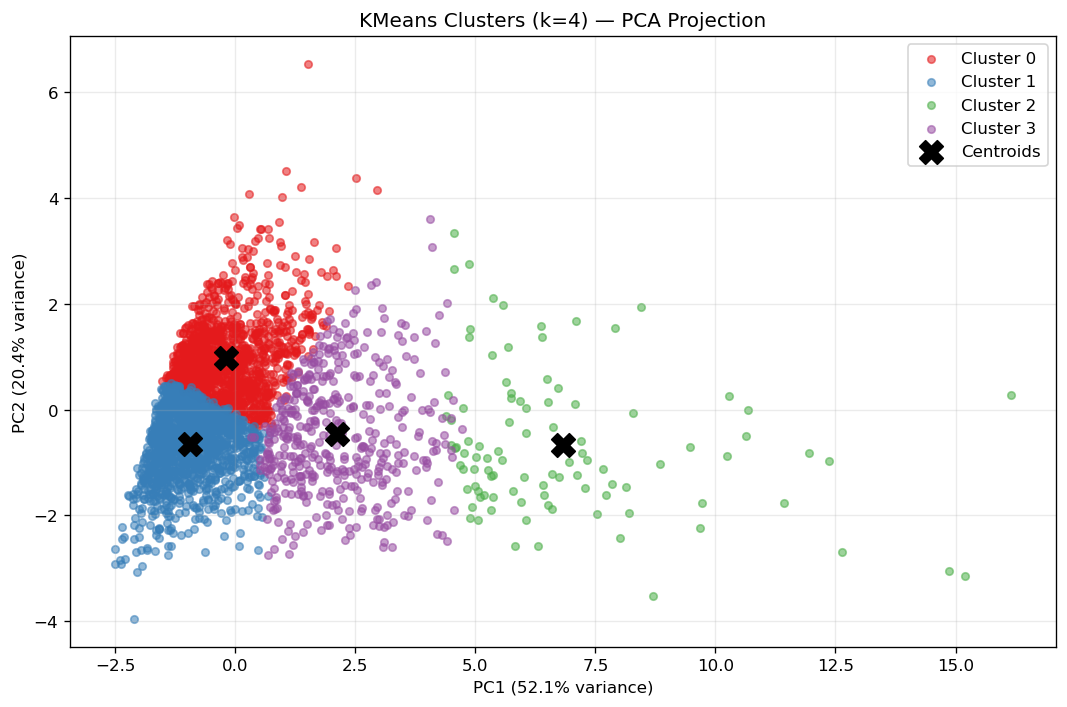


Cluster feature means:


,budget,revenue,popularity,runtime,vote_average,vote_count
cluster,,,,,,
0,2.303206e+07,6.425823e+07,24.60,119.95,6.92,718.86
1,3.050611e+07,5.955644e+07,16.76,99.06,5.66,385.65
2,1.566837e+08,8.105519e+08,141.56,135.11,7.20,6431.49
3,9.822625e+07,3.319082e+08,56.85,117.28,6.53,2436.79


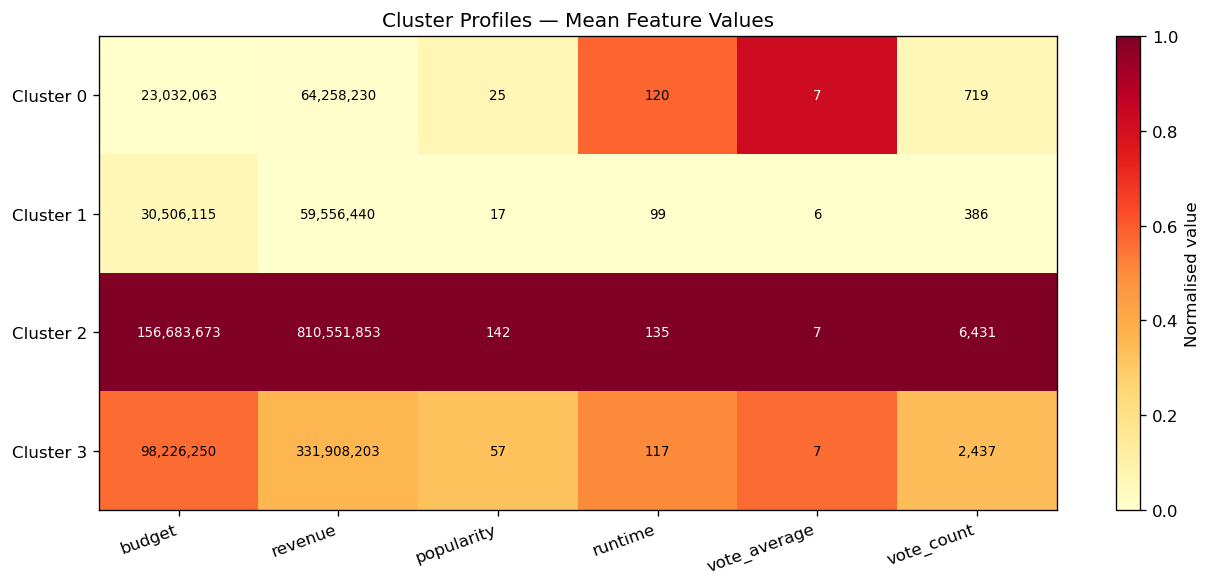

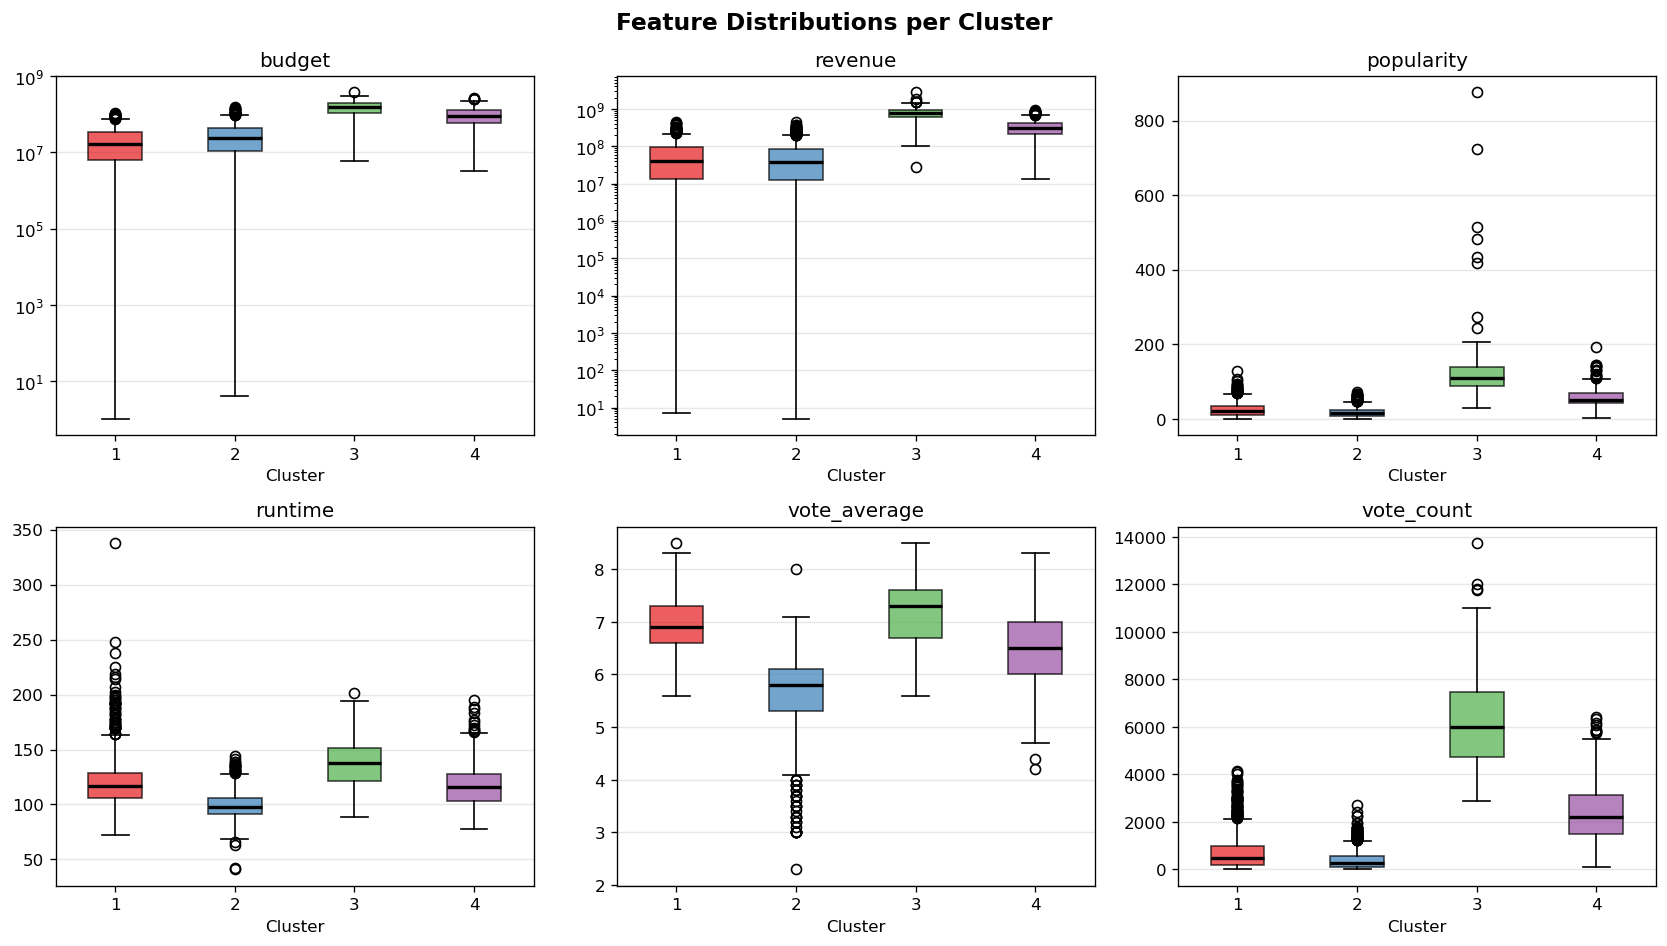


── Cluster 0 — Top 5 by popularity ──


,title,budget,revenue,popularity,vote_average
0,One Flew Over the Cuckoo's Nest,3000000,108981275,127.525581,8.2
1,The Godfather: Part II,13000000,47542841,105.792936,8.3
2,It Follows,2000000,14674076,100.876794,6.6
3,Blade Runner,28000000,33139618,94.056131,7.9
4,Psycho,806948,32000000,93.067866,8.2



── Cluster 1 — Top 5 by popularity ──


,title,budget,revenue,popularity,vote_average
0,Sex Tape,40000000,126069509,72.641296,5.3
1,Dumb and Dumber To,40000000,169837010,67.767785,5.4
2,Sausage Party,19000000,140752617,66.242737,5.6
3,Chronicle,15000000,145000000,64.504747,6.6
4,Carrie,30000000,82394288,63.848541,5.8



── Cluster 2 — Top 5 by popularity ──


,title,budget,revenue,popularity,vote_average
0,Minions,74000000,1156730962,875.581305,6.4
1,Interstellar,165000000,675120017,724.247784,8.1
2,Deadpool,58000000,783112979,514.569956,7.4
3,Guardians of the Galaxy,170000000,773328629,481.098624,7.9
4,Mad Max: Fury Road,150000000,378858340,434.278564,7.2



── Cluster 3 — Top 5 by popularity ──


,title,budget,revenue,popularity,vote_average
0,Whiplash,3300000,13092000,192.528841,8.3
1,The Imitation Game,14000000,233555708,145.364591,8.0
2,Teenage Mutant Ninja Turtles,125000000,477200000,143.350376,5.8
3,Pixels,88000000,243637091,140.849495,5.6
4,Fury,68000000,211817906,139.575085,7.4


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

# ── 1. Load & clean ────────────────────────────────────────────────────────────
df = pd.read_csv("tmdb_5000_movies.csv")   # ← put the CSV in the same folder as this notebook

FEATURES = ["budget", "revenue", "popularity", "runtime", "vote_average", "vote_count"]

df_num = df[FEATURES].copy()
df_num = df_num[(df_num > 0).all(axis=1)].dropna()

print(f"Rows after cleaning: {len(df_num):,} / {len(df):,}")
display(df_num.describe().round(2))

# ── 2. Scale ───────────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)

# ── 3. Elbow + Silhouette ──────────────────────────────────────────────────────
K_RANGE = range(2, 11)
inertias, silhouettes = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=2000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Choosing the Optimal k", fontsize=14, fontweight="bold")

axes[0].plot(K_RANGE, inertias, "o-", color="#1f77b4", linewidth=2)
axes[0].set_title("Elbow Curve (Inertia)")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_RANGE, silhouettes, "o-", color="#ff7f0e", linewidth=2)
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── 4. Fit final model ─────────────────────────────────────────────────────────
BEST_K = 4
km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df_num = df_num.copy()
df_num["cluster"] = km_final.fit_predict(X_scaled)

print(f"\nCluster sizes (k={BEST_K}):")
display(df_num["cluster"].value_counts().sort_index().rename("count").to_frame())

# ── 5. PCA scatter ─────────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
var = pca.explained_variance_ratio_ * 100
PALETTE = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3"]

fig, ax = plt.subplots(figsize=(9, 6))
for c in range(BEST_K):
    mask = df_num["cluster"].values == c
    ax.scatter(coords[mask, 0], coords[mask, 1],
               s=20, alpha=0.55, color=PALETTE[c], label=f"Cluster {c}")

centers_2d = pca.transform(km_final.cluster_centers_)
ax.scatter(centers_2d[:, 0], centers_2d[:, 1],
           s=200, marker="X", color="black", zorder=5, label="Centroids")

ax.set_xlabel(f"PC1 ({var[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({var[1]:.1f}% variance)")
ax.set_title(f"KMeans Clusters (k={BEST_K}) — PCA Projection")
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# ── 6. Cluster profile heatmap ─────────────────────────────────────────────────
cluster_profile = df_num.groupby("cluster")[FEATURES].mean().round(2)
print("\nCluster feature means:")
display(cluster_profile)

profile_norm = (cluster_profile - cluster_profile.min()) / \
               (cluster_profile.max() - cluster_profile.min())

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(profile_norm.values, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=20, ha="right")
ax.set_yticks(range(BEST_K))
ax.set_yticklabels([f"Cluster {c}" for c in range(BEST_K)])
for i in range(BEST_K):
    for j in range(len(FEATURES)):
        val = cluster_profile.iloc[i, j]
        color = "white" if profile_norm.iloc[i, j] > 0.6 else "black"
        ax.text(j, i, f"{val:,.0f}", ha="center", va="center", fontsize=8, color=color)
plt.colorbar(im, ax=ax, label="Normalised value")
ax.set_title("Cluster Profiles — Mean Feature Values")
plt.tight_layout()
plt.show()

# ── 7. Box-plots ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, feat in enumerate(FEATURES):
    data = [df_num.loc[df_num["cluster"] == c, feat].values for c in range(BEST_K)]
    bp = axes[i].boxplot(data, patch_artist=True,
                         medianprops=dict(color="black", linewidth=2))
    for patch, color in zip(bp["boxes"], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(feat)
    axes[i].set_xlabel("Cluster")
    axes[i].set_yscale("log" if df_num[feat].max() > 1e5 else "linear")
    axes[i].grid(True, alpha=0.3, axis="y")
fig.suptitle("Feature Distributions per Cluster", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ── 8. Top-5 movies per cluster ───────────────────────────────────────────────
df_merged = df.loc[df_num.index].copy()
df_merged["cluster"] = df_num["cluster"].values

for c in range(BEST_K):
    top = (df_merged[df_merged["cluster"] == c]
           .nlargest(5, "popularity")
           [["title", "budget", "revenue", "popularity", "vote_average"]])
    print(f"\n── Cluster {c} — Top 5 by popularity ──")
    display(top.reset_index(drop=True))

Rows after cleaning: 3,227 / 4,803


,budget,revenue,popularity,runtime,vote_average,vote_count
count,3.227000e+03,3.227000e+03,3227.00,3227.00,3227.00,3227.00
mean,4.067877e+07,1.213181e+08,29.05,110.72,6.31,977.89
std,4.439974e+07,1.863361e+08,36.17,20.97,0.86,1414.54
min,1.000000e+00,5.000000e+00,0.02,41.00,2.30,1.00
25%,1.050000e+07,1.704008e+07,10.48,96.00,5.80,178.00
50%,2.500000e+07,5.519828e+07,20.42,107.00,6.30,471.00
75%,5.500000e+07,1.463949e+08,37.35,121.00,6.90,1148.00
max,3.800000e+08,2.787965e+09,875.58,338.00,8.50,13752.00


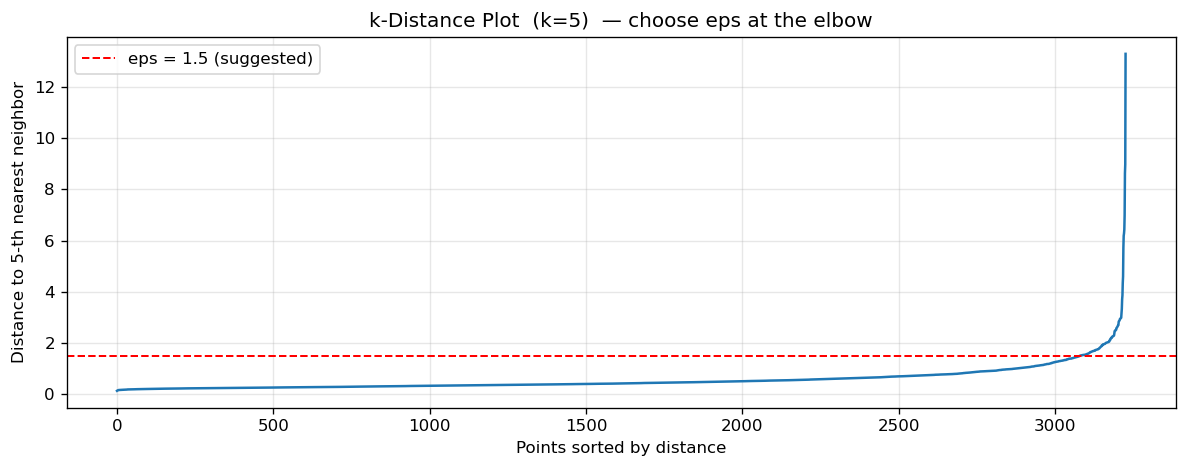


eps=1.5, min_samples=5
Clusters found : 3
Noise points   : 88  (2.7%)



,count
cluster,
Noise (-1),88
Cluster 0,3127
Cluster 1,7
Cluster 2,5


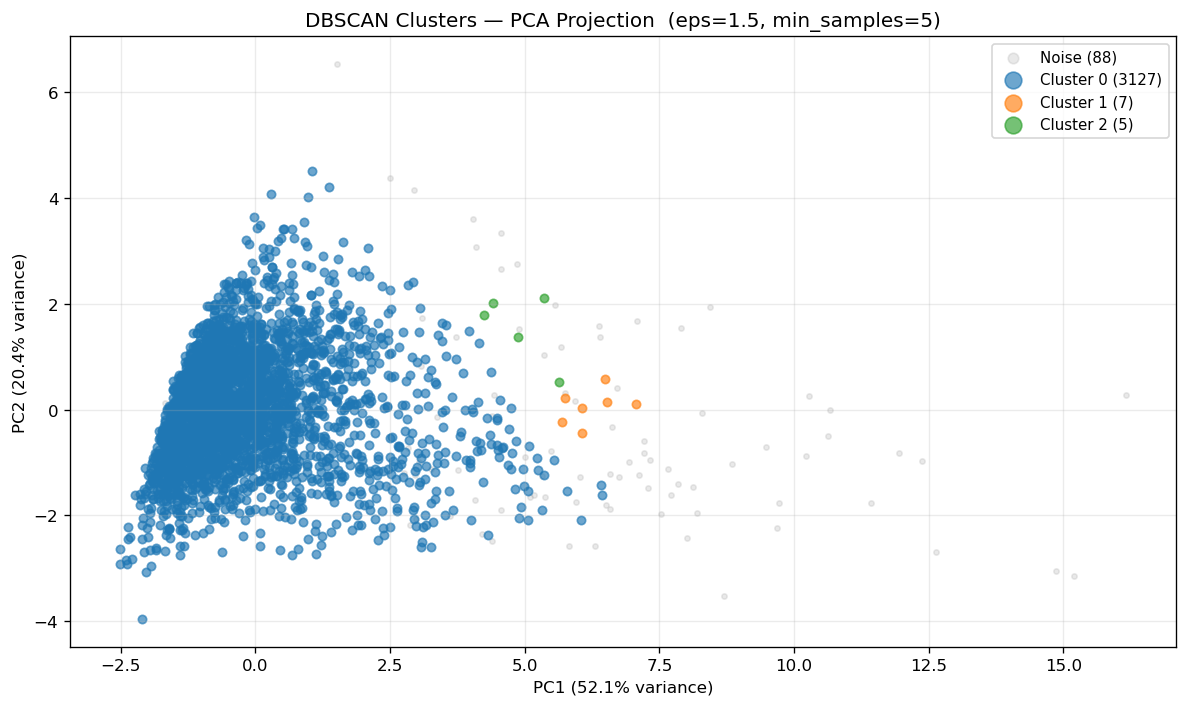


Cluster feature means (noise excluded):


,budget,revenue,popularity,runtime,vote_average,vote_count
cluster,,,,,,
0,3.751362e+07,1.019562e+08,25.65,109.78,6.29,823.27
1,1.364286e+08,8.627561e+08,92.86,147.29,7.50,6008.43
2,9.560000e+07,4.367127e+08,87.92,162.60,7.78,5976.80


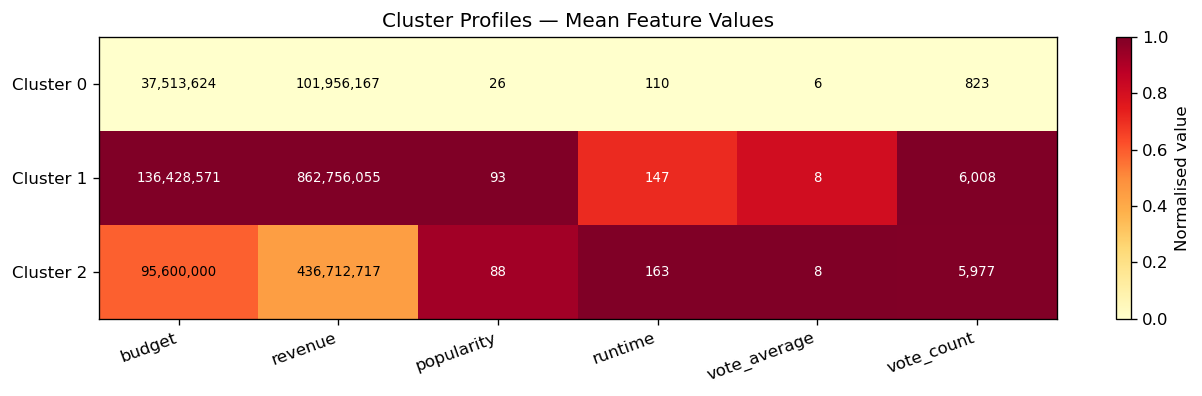

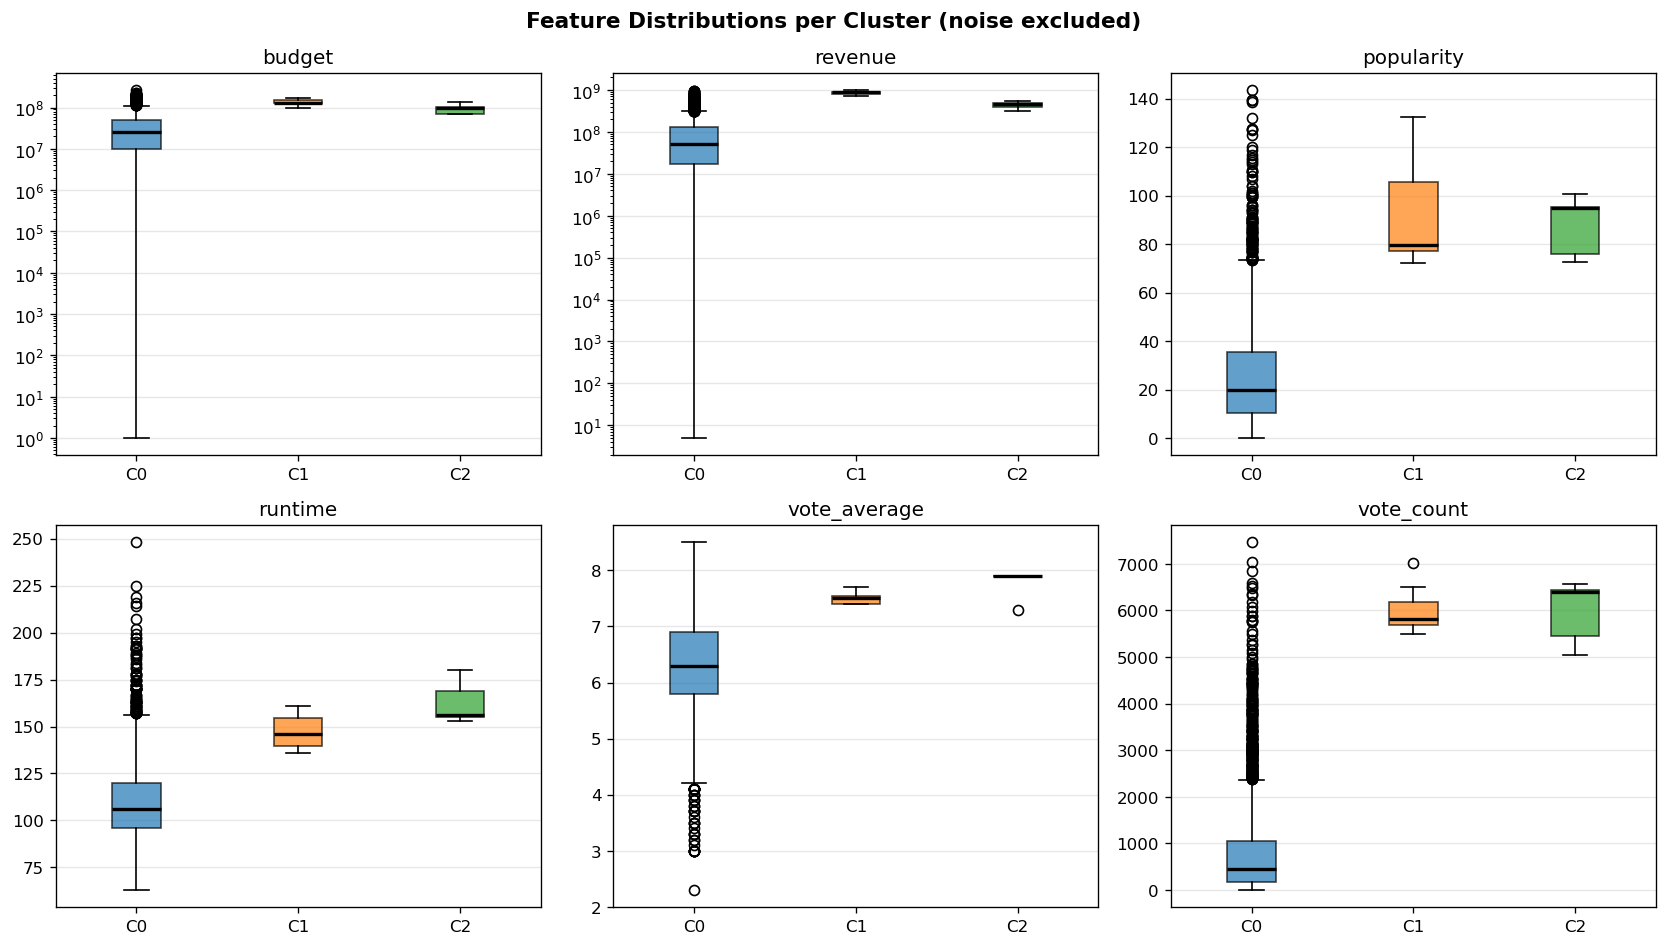


── Noise — Top 5 by popularity ──


,title,budget,revenue,popularity,vote_average
0,Minions,74000000,1156730962,875.581305,6.4
1,Interstellar,165000000,675120017,724.247784,8.1
2,Deadpool,58000000,783112979,514.569956,7.4
3,Guardians of the Galaxy,170000000,773328629,481.098624,7.9
4,Mad Max: Fury Road,150000000,378858340,434.278564,7.2



── Cluster 0 — Top 5 by popularity ──


,title,budget,revenue,popularity,vote_average
0,Teenage Mutant Ninja Turtles,125000000,477200000,143.350376,5.8
1,Fury,68000000,211817906,139.575085,7.4
2,X-Men: Apocalypse,178000000,543934787,139.272042,6.4
3,Rise of the Planet of the Apes,93000000,482860185,138.433168,7.0
4,The Maze Runner,34000000,348319861,131.815575,7.0



── Cluster 1 — Top 5 by popularity ──


,title,budget,revenue,popularity,vote_average
0,Harry Potter and the Chamber of Secrets,100000000,876688482,132.397737,7.4
1,Harry Potter and the Philosopher's Stone,125000000,976475550,109.984351,7.5
2,Harry Potter and the Goblet of Fire,150000000,895921036,101.250416,7.5
3,Harry Potter and the Prisoner of Azkaban,130000000,789804554,79.679601,7.7
4,Harry Potter and the Order of the Phoenix,150000000,938212738,78.144395,7.4



── Cluster 2 — Top 5 by popularity ──


,title,budget,revenue,popularity,vote_average
0,The Revenant,135000000,532950503,100.635882,7.3
1,Gladiator,103000000,457640427,95.301296,7.9
2,The Wolf of Wall Street,100000000,392000694,95.007934,7.9
3,Saving Private Ryan,70000000,481840909,76.041867,7.9
4,Inglourious Basterds,70000000,319131050,72.595961,7.9


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

# ── 1. Load & clean ────────────────────────────────────────────────────────────
df = pd.read_csv("tmdb_5000_movies.csv")   # ← CSV in same folder as notebook

FEATURES = ["budget", "revenue", "popularity", "runtime", "vote_average", "vote_count"]

df_num = df[FEATURES].copy()
df_num = df_num[(df_num > 0).all(axis=1)].dropna()

print(f"Rows after cleaning: {len(df_num):,} / {len(df):,}")
display(df_num.describe().round(2))

# ── 2. Scale ───────────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)

# ── 3. k-distance plot to pick eps ────────────────────────────────────────────
# Sort distances to the k-th nearest neighbor (k = min_samples - 1).
# The "elbow" in this curve is the recommended eps value.
K = 5   # same as min_samples we'll use
nn = NearestNeighbors(n_neighbors=K)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])   # distance to k-th neighbor

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_distances, color="#1f77b4", linewidth=1.5)
ax.set_title(f"k-Distance Plot  (k={K})  — choose eps at the elbow")
ax.set_xlabel("Points sorted by distance")
ax.set_ylabel(f"Distance to {K}-th nearest neighbor")
ax.axhline(y=1.5, color="red", linestyle="--", linewidth=1.2, label="eps = 1.5 (suggested)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 4. Fit DBSCAN ──────────────────────────────────────────────────────────────
EPS        = 1.5   # adjust based on the elbow above
MIN_SAMPLES = 5

db = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
labels = db.fit_predict(X_scaled)
df_num = df_num.copy()
df_num["cluster"] = labels

n_clusters  = len(set(labels)) - (1 if -1 in labels else 0)
n_noise     = (labels == -1).sum()
noise_pct   = n_noise / len(labels) * 100

print(f"\neps={EPS}, min_samples={MIN_SAMPLES}")
print(f"Clusters found : {n_clusters}")
print(f"Noise points   : {n_noise:,}  ({noise_pct:.1f}%)")
print()
counts = df_num["cluster"].value_counts().sort_index().rename("count").to_frame()
counts.index = counts.index.map(lambda x: "Noise (-1)" if x == -1 else f"Cluster {x}")
display(counts)

# ── 5. PCA scatter ─────────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
var = pca.explained_variance_ratio_ * 100

unique_labels = sorted(set(labels))
# build a palette: grey for noise, distinct colors for clusters
cmap = plt.get_cmap("tab10")
color_map = {}
cluster_idx = 0
for lbl in unique_labels:
    if lbl == -1:
        color_map[lbl] = "#aaaaaa"
    else:
        color_map[lbl] = cmap(cluster_idx % 10)
        cluster_idx += 1

fig, ax = plt.subplots(figsize=(10, 6))
for lbl in unique_labels:
    mask  = labels == lbl
    name  = "Noise" if lbl == -1 else f"Cluster {lbl}"
    alpha = 0.25 if lbl == -1 else 0.65
    size  = 10   if lbl == -1 else 25
    ax.scatter(coords[mask, 0], coords[mask, 1],
               s=size, alpha=alpha, color=color_map[lbl], label=f"{name} ({mask.sum()})")

ax.set_xlabel(f"PC1 ({var[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({var[1]:.1f}% variance)")
ax.set_title(f"DBSCAN Clusters — PCA Projection  (eps={EPS}, min_samples={MIN_SAMPLES})")
ax.legend(markerscale=2, fontsize=9)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# ── 6. Cluster profile heatmap (excluding noise) ───────────────────────────────
df_clean = df_num[df_num["cluster"] != -1]
if df_clean["cluster"].nunique() > 1:
    cluster_profile = df_clean.groupby("cluster")[FEATURES].mean().round(2)
    print("\nCluster feature means (noise excluded):")
    display(cluster_profile)

    profile_norm = (cluster_profile - cluster_profile.min()) / \
                   (cluster_profile.max() - cluster_profile.min() + 1e-9)

    fig, ax = plt.subplots(figsize=(11, max(3, n_clusters * 0.8 + 1)))
    im = ax.imshow(profile_norm.values, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(len(FEATURES)))
    ax.set_xticklabels(FEATURES, rotation=20, ha="right")
    ax.set_yticks(range(n_clusters))
    ax.set_yticklabels([f"Cluster {c}" for c in cluster_profile.index])
    for i in range(n_clusters):
        for j in range(len(FEATURES)):
            val   = cluster_profile.iloc[i, j]
            color = "white" if profile_norm.iloc[i, j] > 0.6 else "black"
            ax.text(j, i, f"{val:,.0f}", ha="center", va="center", fontsize=8, color=color)
    plt.colorbar(im, ax=ax, label="Normalised value")
    ax.set_title("Cluster Profiles — Mean Feature Values")
    plt.tight_layout()
    plt.show()
else:
    print("Only one real cluster found — try lowering eps or min_samples.")

# ── 7. Box-plots per cluster (noise excluded) ──────────────────────────────────
if df_clean["cluster"].nunique() > 0:
    real_clusters = sorted(df_clean["cluster"].unique())
    cmap2 = plt.get_cmap("tab10")

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()
    for i, feat in enumerate(FEATURES):
        data = [df_clean.loc[df_clean["cluster"] == c, feat].values for c in real_clusters]
        bp = axes[i].boxplot(data, patch_artist=True,
                             medianprops=dict(color="black", linewidth=2))
        for patch, c in zip(bp["boxes"], real_clusters):
            patch.set_facecolor(cmap2(c % 10))
            patch.set_alpha(0.7)
        axes[i].set_title(feat)
        axes[i].set_xticklabels([f"C{c}" for c in real_clusters])
        axes[i].set_yscale("log" if df_num[feat].max() > 1e5 else "linear")
        axes[i].grid(True, alpha=0.3, axis="y")
    fig.suptitle("Feature Distributions per Cluster (noise excluded)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

# ── 8. Top-5 movies per cluster ───────────────────────────────────────────────
df_merged = df.loc[df_num.index].copy()
df_merged["cluster"] = df_num["cluster"].values

for c in sorted(df_merged["cluster"].unique()):
    label = "Noise" if c == -1 else f"Cluster {c}"
    top = (df_merged[df_merged["cluster"] == c]
           .nlargest(5, "popularity")
           [["title", "budget", "revenue", "popularity", "vote_average"]])
    print(f"\n── {label} — Top 5 by popularity ──")
    display(top.reset_index(drop=True))

eps=1.5, min_samples=5
Clusters : 3
Noise    : 88 (2.7%)

Overall silhouette score (noise excluded): 0.5431
  Interpretation: -1 = wrong cluster, 0 = overlapping, +1 = perfect separation

Per-cluster silhouette summary:


,Size,Mean sil,Min sil,Max sil
Cluster,,,,
0,3127,0.5434,-0.6885,0.7162
1,7,0.4816,0.3220,0.5830
2,5,0.4290,0.1398,0.5239


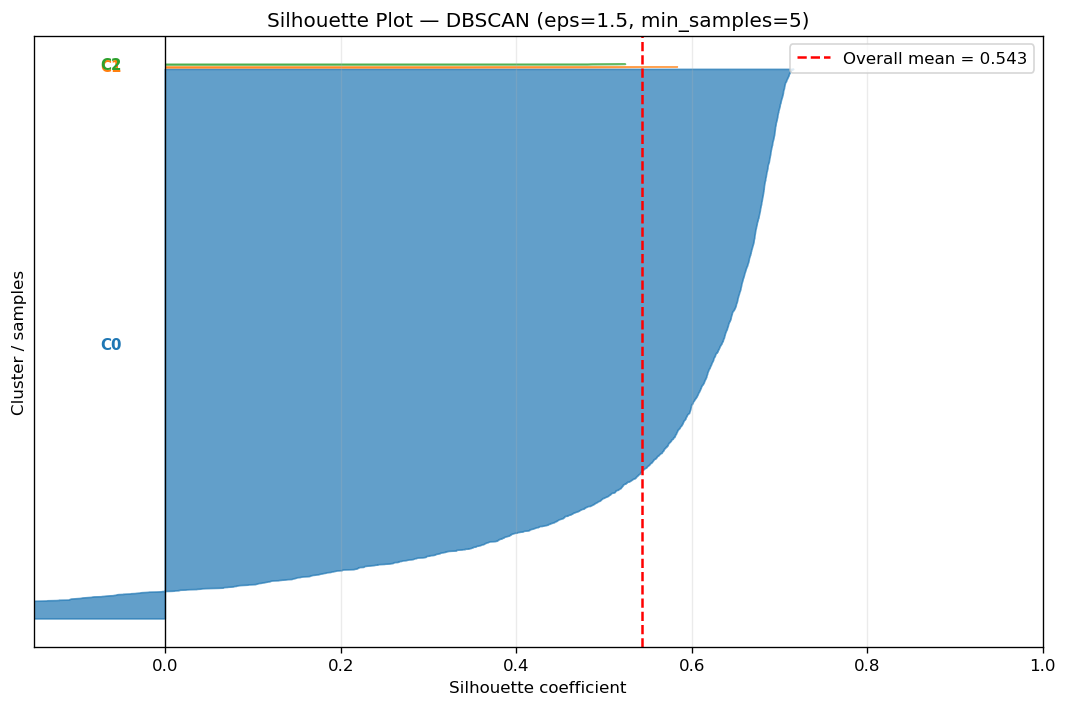


Searching best eps (min_samples fixed)...


,eps,clusters,noise,silhouette
0,0.50,7,972,0.0388
1,0.75,5,450,0.2685
2,1.00,1,261,NaN
3,1.25,3,165,0.5237
4,1.50,3,88,0.5431
5,1.75,1,54,NaN
6,2.00,1,38,NaN
7,2.25,1,22,NaN
8,2.50,1,17,NaN
9,2.75,1,14,NaN


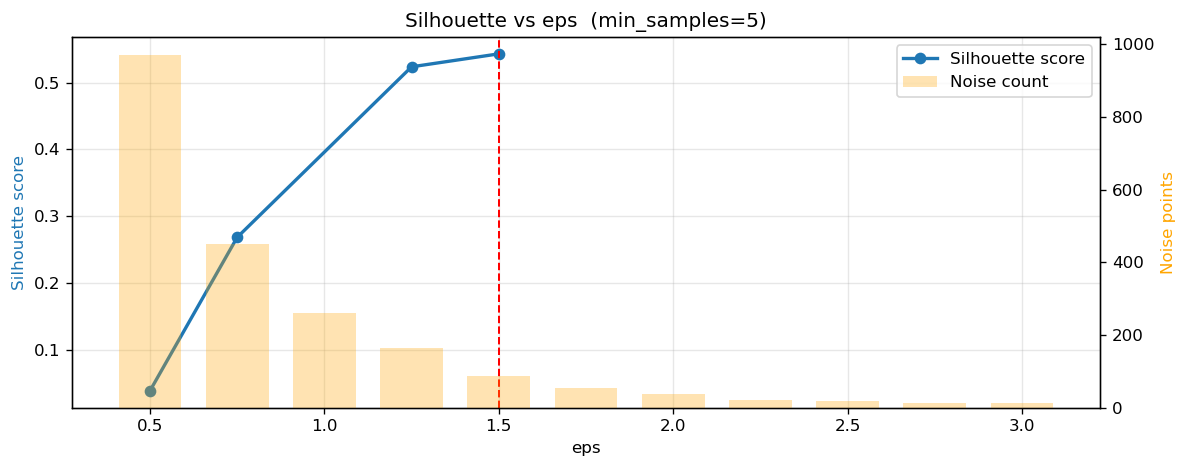


Best eps by silhouette: 1.5  →  score = 0.5431


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

# ── 1. Load, clean, scale (same as before) ────────────────────────────────────
df = pd.read_csv("tmdb_5000_movies.csv")

FEATURES = ["budget", "revenue", "popularity", "runtime", "vote_average", "vote_count"]
df_num = df[FEATURES].copy()
df_num = df_num[(df_num > 0).all(axis=1)].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)

# ── 2. Fit DBSCAN ──────────────────────────────────────────────────────────────
EPS         = 1.5
MIN_SAMPLES = 5

labels = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES).fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = (labels == -1).sum()
print(f"eps={EPS}, min_samples={MIN_SAMPLES}")
print(f"Clusters : {n_clusters}")
print(f"Noise    : {n_noise} ({n_noise/len(labels)*100:.1f}%)\n")

# ── 3. Overall silhouette score (noise excluded) ───────────────────────────────
# Silhouette is undefined for noise points (label = -1), so we drop them.
mask       = labels != -1
X_core     = X_scaled[mask]
labels_core = labels[mask]

if len(set(labels_core)) < 2:
    print("Only one cluster found — silhouette score requires at least 2 clusters.")
    print("Try lowering eps or min_samples.")
else:
    overall = silhouette_score(X_core, labels_core)
    print(f"Overall silhouette score (noise excluded): {overall:.4f}")
    print("  Interpretation: -1 = wrong cluster, 0 = overlapping, +1 = perfect separation\n")

    # ── 4. Per-sample silhouette values ───────────────────────────────────────
    sample_vals = silhouette_samples(X_core, labels_core)

    # ── 5. Per-cluster silhouette summary ─────────────────────────────────────
    unique_clusters = sorted(set(labels_core))
    summary = []
    for c in unique_clusters:
        c_vals = sample_vals[labels_core == c]
        summary.append({
            "Cluster"  : c,
            "Size"     : len(c_vals),
            "Mean sil" : round(c_vals.mean(), 4),
            "Min sil"  : round(c_vals.min(),  4),
            "Max sil"  : round(c_vals.max(),  4),
        })
    summary_df = pd.DataFrame(summary).set_index("Cluster")
    print("Per-cluster silhouette summary:")
    display(summary_df)

    # ── 6. Silhouette plot (one band per cluster) ──────────────────────────────
    fig, ax = plt.subplots(figsize=(9, max(4, n_clusters * 2)))

    y_lower = 10
    cmap    = cm.get_cmap("tab10")

    for idx, c in enumerate(unique_clusters):
        c_vals = np.sort(sample_vals[labels_core == c])
        size   = len(c_vals)
        y_upper = y_lower + size

        color = cmap(idx % 10)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_vals,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + size / 2, f"C{c}", fontsize=9,
                va="center", ha="right", color=color, fontweight="bold")

        y_lower = y_upper + 10   # gap between bands

    ax.axvline(x=overall, color="red", linestyle="--", linewidth=1.5,
               label=f"Overall mean = {overall:.3f}")
    ax.axvline(x=0, color="black", linestyle="-", linewidth=0.8)

    ax.set_xlabel("Silhouette coefficient")
    ax.set_ylabel("Cluster / samples")
    ax.set_title(f"Silhouette Plot — DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES})")
    ax.set_yticks([])
    ax.legend(loc="upper right")
    ax.set_xlim(-0.15, 1.0)
    ax.grid(True, alpha=0.25, axis="x")
    plt.tight_layout()
    plt.show()

    # ── 7. Sweep eps to find best silhouette ──────────────────────────────────
    print("\nSearching best eps (min_samples fixed)...")
    eps_values  = np.arange(0.5, 3.1, 0.25)
    results = []

    for eps in eps_values:
        lbl = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit_predict(X_scaled)
        mk  = lbl != -1
        n_c = len(set(lbl[mk]))
        n_n = (lbl == -1).sum()
        if n_c >= 2 and mk.sum() > n_c:
            sil = silhouette_score(X_scaled[mk], lbl[mk])
        else:
            sil = np.nan
        results.append({"eps": round(eps, 2), "clusters": n_c,
                         "noise": n_n, "silhouette": round(sil, 4) if not np.isnan(sil) else np.nan})

    results_df = pd.DataFrame(results)
    display(results_df)

    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax2 = ax1.twinx()

    valid = results_df.dropna(subset=["silhouette"])
    ax1.plot(valid["eps"], valid["silhouette"], "o-", color="#1f77b4",
             linewidth=2, label="Silhouette score")
    ax2.bar(results_df["eps"], results_df["noise"], width=0.18,
            alpha=0.3, color="orange", label="Noise count")

    ax1.set_xlabel("eps")
    ax1.set_ylabel("Silhouette score", color="#1f77b4")
    ax2.set_ylabel("Noise points", color="orange")
    ax1.set_title(f"Silhouette vs eps  (min_samples={MIN_SAMPLES})")
    ax1.grid(True, alpha=0.3)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    best_eps = valid.loc[valid["silhouette"].idxmax(), "eps"]
    ax1.axvline(x=best_eps, color="red", linestyle="--",
                linewidth=1.2, label=f"Best eps = {best_eps}")
    plt.tight_layout()
    plt.show()
    print(f"\nBest eps by silhouette: {best_eps}  →  score = {valid['silhouette'].max():.4f}")

Dataset shape: (3227, 6)
  k=2  SSE=    13,168.0  Silhouette=0.5227
  k=3  SSE=    10,802.6  Silhouette=0.2533
  k=4  SSE=     9,432.9  Silhouette=0.2439
  k=5  SSE=     8,417.1  Silhouette=0.2452
  k=6  SSE=     7,416.6  Silhouette=0.2251
  k=7  SSE=     6,672.0  Silhouette=0.2346
  k=8  SSE=     6,177.4  Silhouette=0.2365
  k=9  SSE=     5,807.6  Silhouette=0.2137
  k=10  SSE=     5,506.5  Silhouette=0.2141


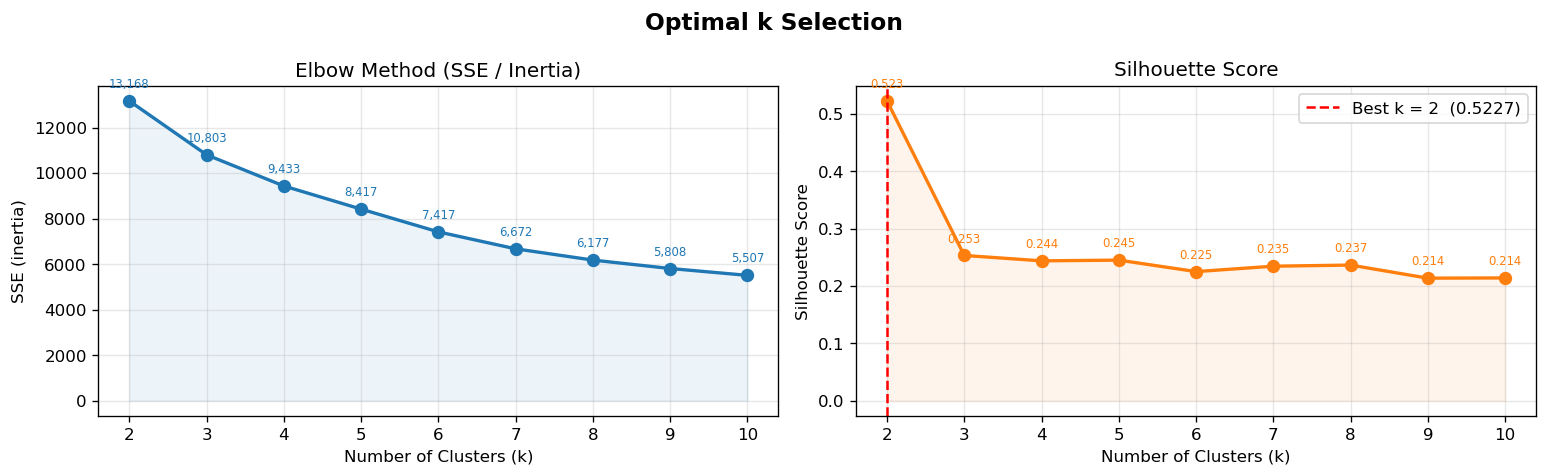


Evaluation table:


<class 'AttributeError'>: The '.style' accessor requires jinja2

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

# ── 1. Load, clean, scale ─────────────────────────────────────────────────────
df = pd.read_csv("tmdb_5000_movies.csv")

FEATURES = ["budget", "revenue", "popularity", "runtime", "vote_average", "vote_count"]
df_num = df[FEATURES].copy()
df_num = df_num[(df_num > 0).all(axis=1)].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)

print(f"Dataset shape: {df_num.shape}")

# ── 2. Compute SSE (inertia) + Silhouette for k = 2..10 ──────────────────────
K_RANGE = range(2, 11)
sse, sil_scores = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sse.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels, sample_size=2000, random_state=42))
    print(f"  k={k}  SSE={km.inertia_:>12,.1f}  Silhouette={sil_scores[-1]:.4f}")

# ── 3. Elbow + Silhouette side-by-side ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Optimal k Selection", fontsize=14, fontweight="bold")

# — Elbow / SSE —
axes[0].plot(K_RANGE, sse, "o-", color="#1f77b4", linewidth=2, markersize=7)
axes[0].fill_between(K_RANGE, sse, alpha=0.08, color="#1f77b4")
axes[0].set_title("Elbow Method (SSE / Inertia)")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("SSE (inertia)")
axes[0].grid(True, alpha=0.3)

# annotate each point with SSE value
for k, s in zip(K_RANGE, sse):
    axes[0].annotate(f"{s:,.0f}", (k, s), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=7, color="#1f77b4")

# — Silhouette —
best_k = list(K_RANGE)[sil_scores.index(max(sil_scores))]
axes[1].plot(K_RANGE, sil_scores, "o-", color="#ff7f0e", linewidth=2, markersize=7)
axes[1].fill_between(K_RANGE, sil_scores, alpha=0.08, color="#ff7f0e")
axes[1].axvline(x=best_k, color="red", linestyle="--", linewidth=1.5,
                label=f"Best k = {best_k}  ({max(sil_scores):.4f})")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for k, s in zip(K_RANGE, sil_scores):
    axes[1].annotate(f"{s:.3f}", (k, s), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=7, color="#ff7f0e")

plt.tight_layout()
plt.show()

# ── 4. SSE improvement table ──────────────────────────────────────────────────
sse_diff  = [None] + [sse[i-1] - sse[i] for i in range(1, len(sse))]
sse_pct   = [None] + [round((sse[i-1] - sse[i]) / sse[i-1] * 100, 2) for i in range(1, len(sse))]

eval_df = pd.DataFrame({
    "k"              : list(K_RANGE),
    "SSE"            : [round(s, 1) for s in sse],
    "SSE drop"       : [round(d, 1) if d else None for d in sse_diff],
    "SSE drop %"     : sse_pct,
    "Silhouette"     : [round(s, 4) for s in sil_scores],
}).set_index("k")

print("\nEvaluation table:")
display(eval_df.style
        .highlight_max(subset=["Silhouette"], color="#c6efce")
        .highlight_min(subset=["SSE"],        color="#c6efce")
        .format({"SSE": "{:,.1f}", "SSE drop": "{:,.1f}", "SSE drop %": "{:.2f}%",
                 "Silhouette": "{:.4f}"}, na_rep="—"))

# ── 5. Fit final model with best k ────────────────────────────────────────────
print(f"\nFitting final KMeans with k = {best_k} ...")
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_final = km_final.fit_predict(X_scaled)
df_num = df_num.copy()
df_num["cluster"] = labels_final

print(f"SSE (inertia)       : {km_final.inertia_:,.2f}")
print(f"Silhouette score    : {silhouette_score(X_scaled, labels_final):.4f}")
print(f"\nCluster sizes:")
display(df_num["cluster"].value_counts().sort_index().rename("count").to_frame())

# ── 6. Silhouette plot for best k ─────────────────────────────────────────────
sample_vals = silhouette_samples(X_scaled, labels_final)
overall_sil = sample_vals.mean()
cmap = cm.get_cmap("tab10")

fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 10

for c in range(best_k):
    c_vals = np.sort(sample_vals[labels_final == c])
    y_upper = y_lower + len(c_vals)
    color = cmap(c % 10)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_vals,
                     facecolor=color, edgecolor=color, alpha=0.75)
    ax.text(-0.05, y_lower + len(c_vals) / 2, f"C{c}",
            fontsize=9, va="center", ha="right", color=color, fontweight="bold")
    y_lower = y_upper + 10

ax.axvline(x=overall_sil, color="red", linestyle="--", linewidth=1.5,
           label=f"Mean = {overall_sil:.4f}")
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Samples (grouped by cluster)")
ax.set_title(f"Silhouette Plot — KMeans k={best_k}")
ax.set_yticks([])
ax.set_xlim(-0.2, 1.0)
ax.legend()
ax.grid(True, alpha=0.25, axis="x")
plt.tight_layout()
plt.show()

# ── 7. Per-cluster silhouette summary ─────────────────────────────────────────
rows = []
for c in range(best_k):
    v = sample_vals[labels_final == c]
    rows.append({
        "Cluster"          : c,
        "Size"             : len(v),
        "Mean silhouette"  : round(v.mean(), 4),
        "Min silhouette"   : round(v.min(),  4),
        "Max silhouette"   : round(v.max(),  4),
        "Below mean (%)"   : round((v < overall_sil).mean() * 100, 1),
    })

summary_df = pd.DataFrame(rows).set_index("Cluster")
print("\nPer-cluster silhouette summary:")
display(summary_df.style
        .highlight_max(subset=["Mean silhouette"], color="#c6efce")
        .highlight_min(subset=["Mean silhouette"], color="#ffc7ce")
        .format({"Mean silhouette": "{:.4f}", "Min silhouette": "{:.4f}",
                 "Max silhouette": "{:.4f}", "Below mean (%)": "{:.1f}%"}))